(sensitivity_confounding)=
# Sensitivity Analysis for Unmeasured Confounding

:::{post} May 2026
:tags: experimentation, sensitivity analysis, causal inference, confounding, robustness
:category: intermediate, reference
:author: Nathaniel Forde
:::

## The randomisation gap

Randomisation is an assumption you maintain by design, not a fact you assert by intention. The checkout experiment ran, the headline effect on revenue-per-visitor looks positive, and somewhere in the diagnostic notes there is a line about compliance being 73%: users on slow connections were silently routed back to the old flow by a CDN edge case, and the routing was not random in the way it touched the population. The intent-to-treat estimate now depends on a counterfactual the experiment did not produce: what those users would have done under the new flow. Without further assumptions, the data cannot say what the treatment effect would have been if randomisation had held.

This notebook develops the Bayesian response to this situation. Where Rosenbaum's $\Gamma$ {cite:p}`rosenbaum2002observational` and the E-value {cite:p}`vanderweele2017sensitivity` give point summaries of how strong an unmeasured confounder would need to be to nullify the result, the Bayesian framing makes the same unmeasured confounder a *parameter* in the model, with a prior over its plausible strength and a posterior shaped by both the data and the analyst's commitments {cite:p}`imbens2003sensitivity`, {cite:p}`cinellihazlett2020omitted`. We develop the machinery on a continuous outcome (revenue per visitor) and then re-run it on a binary outcome (conversion). This is the second of three notebooks on the lifecycle of a Bayesian experiment; see {ref}`assurance_planning` for the planning counterpart and {ref}`meta_analysis_experiments` for the synthesis counterpart.

:::{admonition} Where this lands in regulatory practice
:class: note

The sensitivity construction here is not a workaround; it is the regulatory recommendation. The FDA's 2026 draft guidance on Bayesian methodology in clinical trials describes sensitivity analysis as varying the prior over a critical assumption, and notes that "some approaches can build uncertainty about specific assumptions into the prior itself" {cite:p}`fda2026bayesian`, which is the move made below. The guidance goes further and sanctions modelling a discrepancy between data sources with "an assumed bias parameter in the model", the exact object this notebook places a prior on and sweeps. The clinical-trial setting differs from a product quasi-experiment; the bias parameter is the same.
:::

In [1]:
import warnings

from dataclasses import dataclass

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-variat")
rng = np.random.default_rng(7)
RANDOM_SEED = 7

## What the data can and cannot say

The structural picture is small and the notation traditional. Let $T$ be the observed treatment indicator (which flow the visitor actually saw), let $Y$ be the outcome (revenue), and let $U$ be an unmeasured user characteristic: connection quality, engagement disposition, whatever drives the differential compliance. Under randomisation $U$ is independent of $T$ by construction; under compliance failure $U$ is associated with $T$ and unobservable.

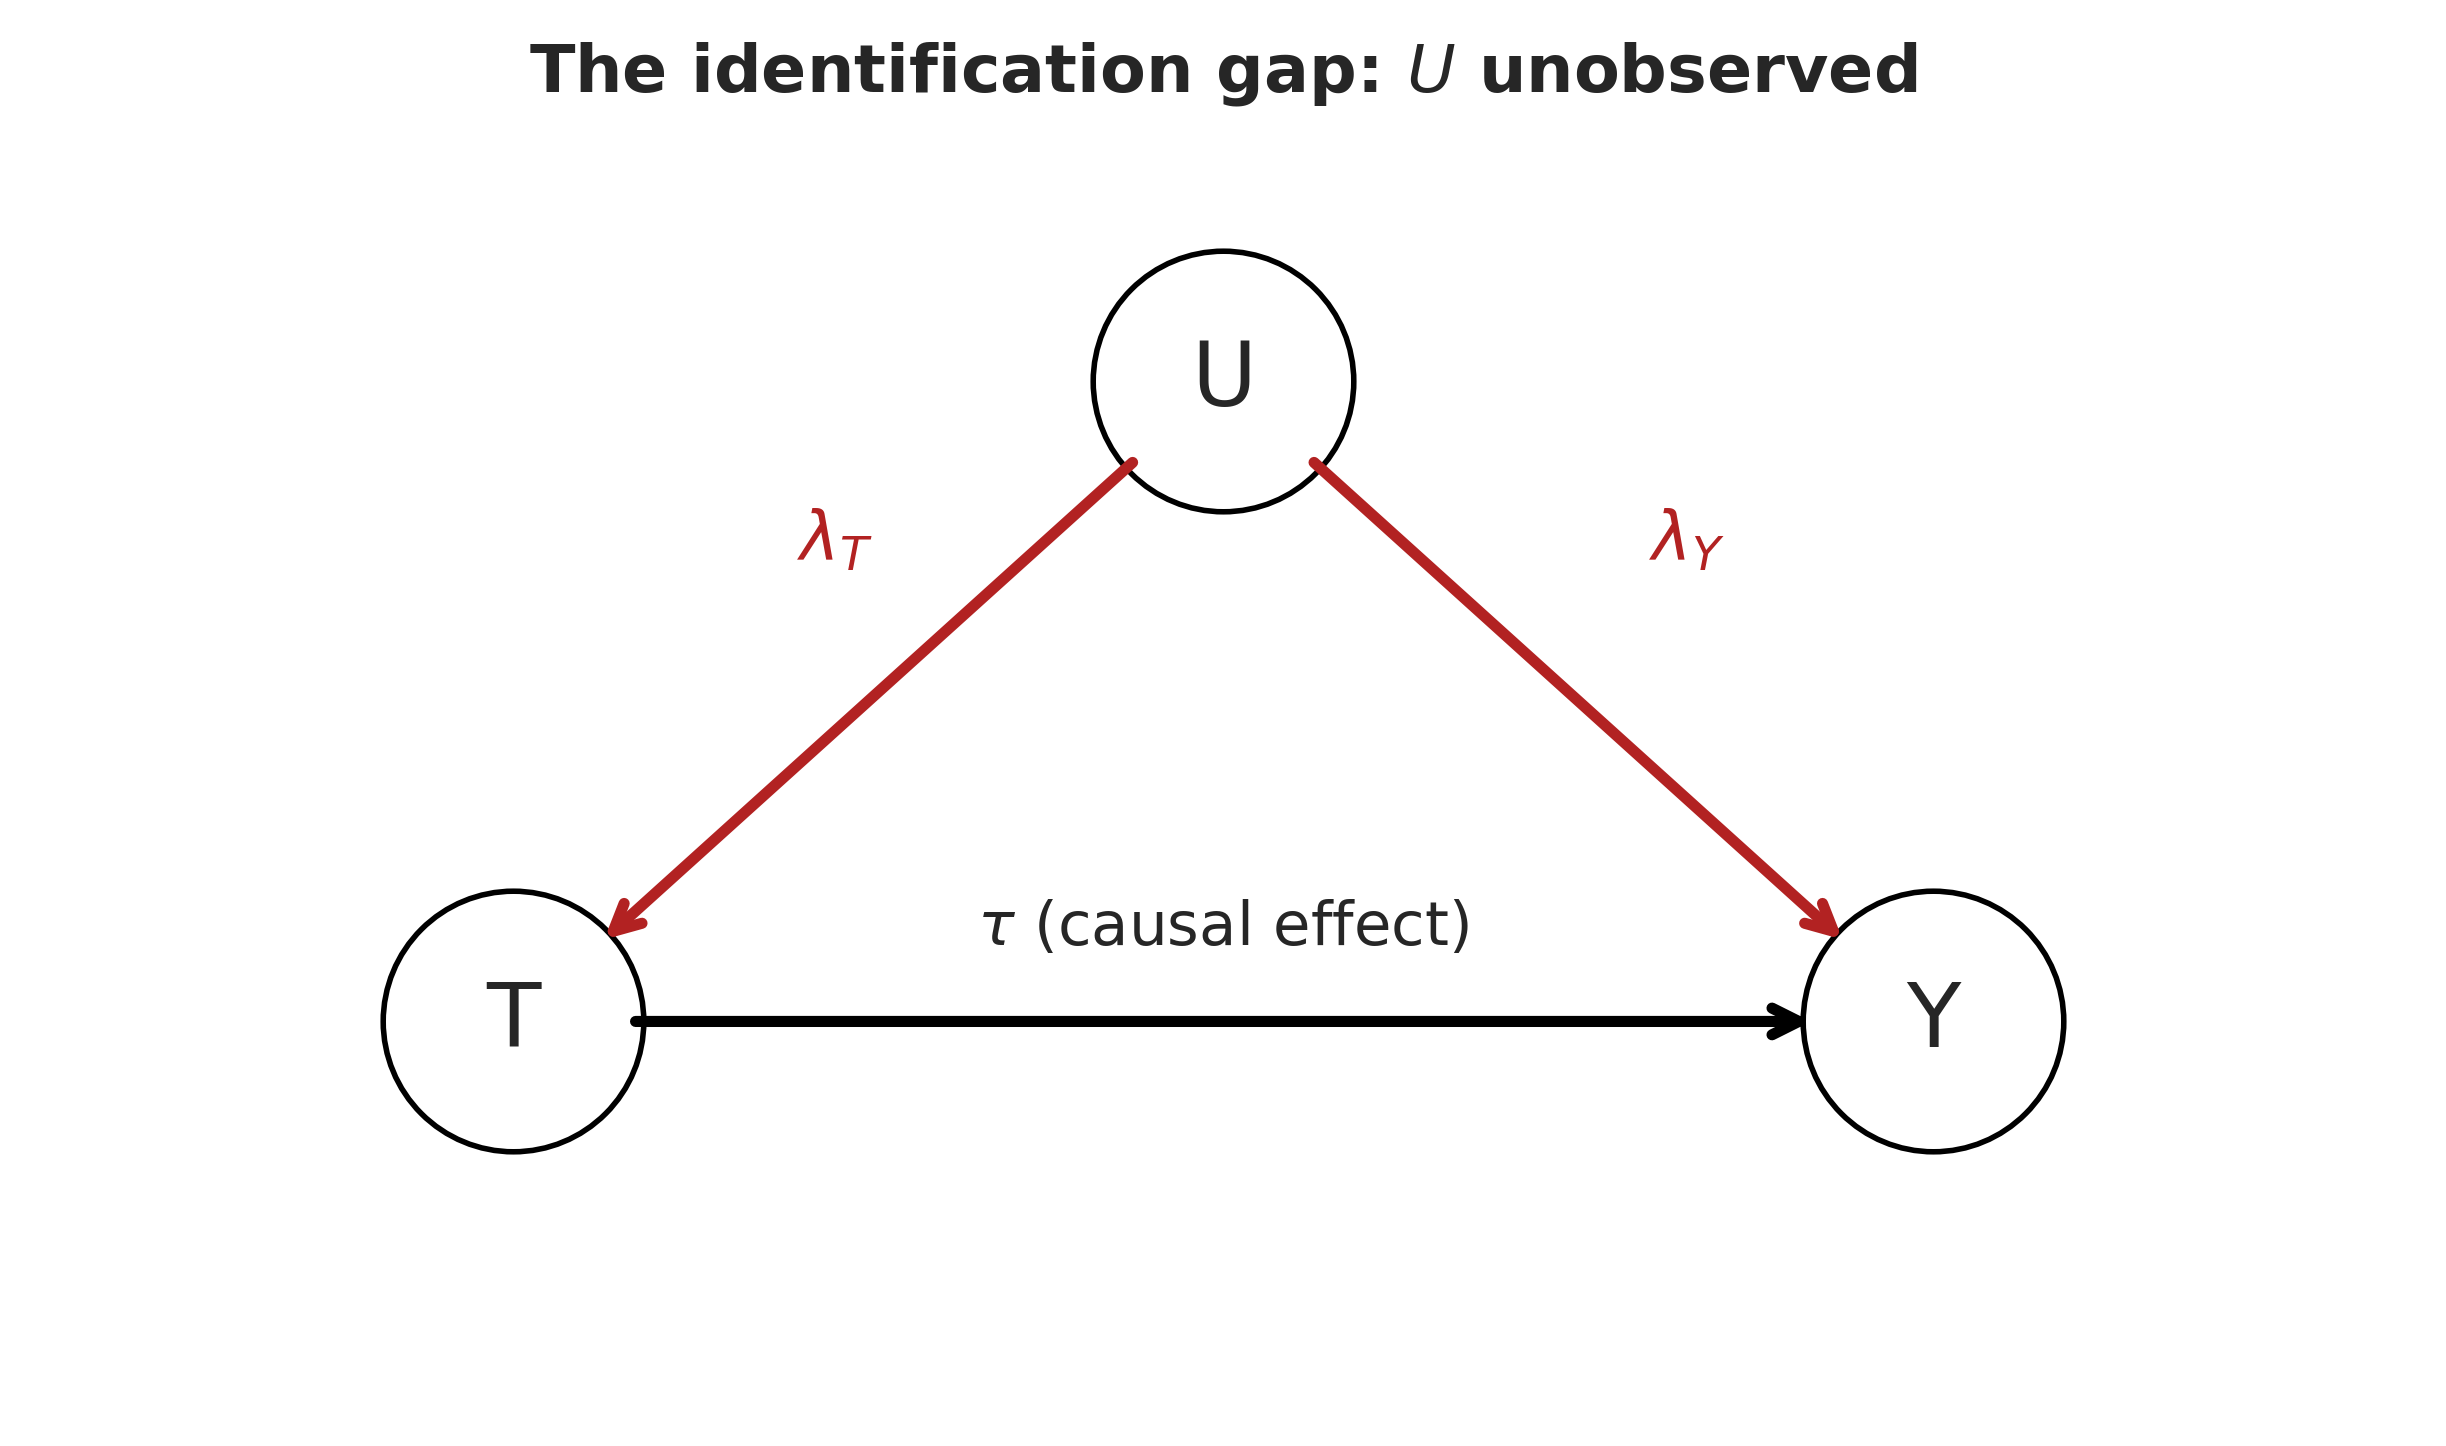

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

nodes = {"T": (2, 1.5), "Y": (8, 1.5), "U": (5, 4)}
for name, (x, y) in nodes.items():
    ax.scatter(x, y, s=2200, facecolor="white", edgecolor="black", zorder=3)
    ax.text(x, y, name, ha="center", va="center", fontsize=16, zorder=4)


def arrow(a, b, **kw):
    (x0, y0), (x1, y1) = nodes[a], nodes[b]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", lw=2, shrinkA=22, shrinkB=22, **kw),
    )


arrow("T", "Y")
arrow("U", "T", color="firebrick")
arrow("U", "Y", color="firebrick")

ax.text(5, 1.8, r"$\tau$ (causal effect)", ha="center", fontsize=11)
ax.text(3.2, 3.3, r"$\lambda_T$", color="firebrick", fontsize=12)
ax.text(6.8, 3.3, r"$\lambda_Y$", color="firebrick", fontsize=12)
ax.set_title("The identification gap: $U$ unobserved", fontsize=12);

What we want is $\tau$, the causal effect of $T$ on $Y$. What the data identify is $\tau$ *plus* the contribution of any path that flows through $U$ — specifically the product of the two red edges, which we collect into a single bias term $\beta = \lambda_T \cdot \lambda_Y / \mathrm{var}(T)$ at the scale of the observed difference in means {cite:p}`hernan2020whatif`, {cite:p}`cunningham2021causal`. The naïve estimator returns $\tau + \beta$. The data are silent on the decomposition; the prior is what sets it.

## The bias parameter

The Bayesian sensitivity analysis makes $\beta$ a model parameter with a prior. The data inform the sum $\tau + \beta$ through the observed difference; the prior on $\beta$ controls how much of that sum is attributed to the unmeasured confounder rather than to the treatment. Three prior commitments:

- **Dismissive prior** ($\beta \sim \mathcal{N}(0, 0.05)$): "I am confident there is essentially no confounding."
- **Moderate prior** ($\beta \sim \mathcal{N}(0, 0.3)$): "I will allow that confounding may have shifted the apparent effect by up to a few tenths of a revenue unit."
- **Sceptical prior** ($\beta \sim \mathcal{N}(0, 0.7)$): "I will not commit to confounding being small; the data must speak loudly to be heard."

Each is an auditable commitment.

In [4]:
N = 4000
TRUE_TAU = 0.30
TRUE_BIAS = 0.50
SIGMA_OBS = 4.0


def simulate_quasi_experimental_gaussian(N, true_tau, true_bias, sigma_obs, rng):
    baseline = 10.0
    y_A = rng.normal(baseline, sigma_obs, size=N)
    y_B = rng.normal(baseline + true_tau + true_bias, sigma_obs, size=N)
    return y_A, y_B


y_A_obs, y_B_obs = simulate_quasi_experimental_gaussian(N, TRUE_TAU, TRUE_BIAS, SIGMA_OBS, rng)
d_hat = y_B_obs.mean() - y_A_obs.mean()
sigma_d = np.sqrt(2 * SIGMA_OBS**2 / N)
print(f"Observed difference d_hat = {d_hat:.3f} (sampling SE = {sigma_d:.3f})")
print(f"True tau = {TRUE_TAU}, true bias = {TRUE_BIAS}, true sum = {TRUE_TAU + TRUE_BIAS}")

Observed difference d_hat = 0.793 (sampling SE = 0.089)
True tau = 0.3, true bias = 0.5, true sum = 0.8


The observed difference recovers the *biased* effect, as it must. $\tau$ is what we want; $\beta$ is what we cannot observe. The model below asks which decomposition the data find most plausible given a prior on $\beta$.

NUTS[nutpie]: [tau, beta]


Text(0.5, 1.05, 'Posterior of $\\tau$ and $\\beta$ under a moderate bias prior')

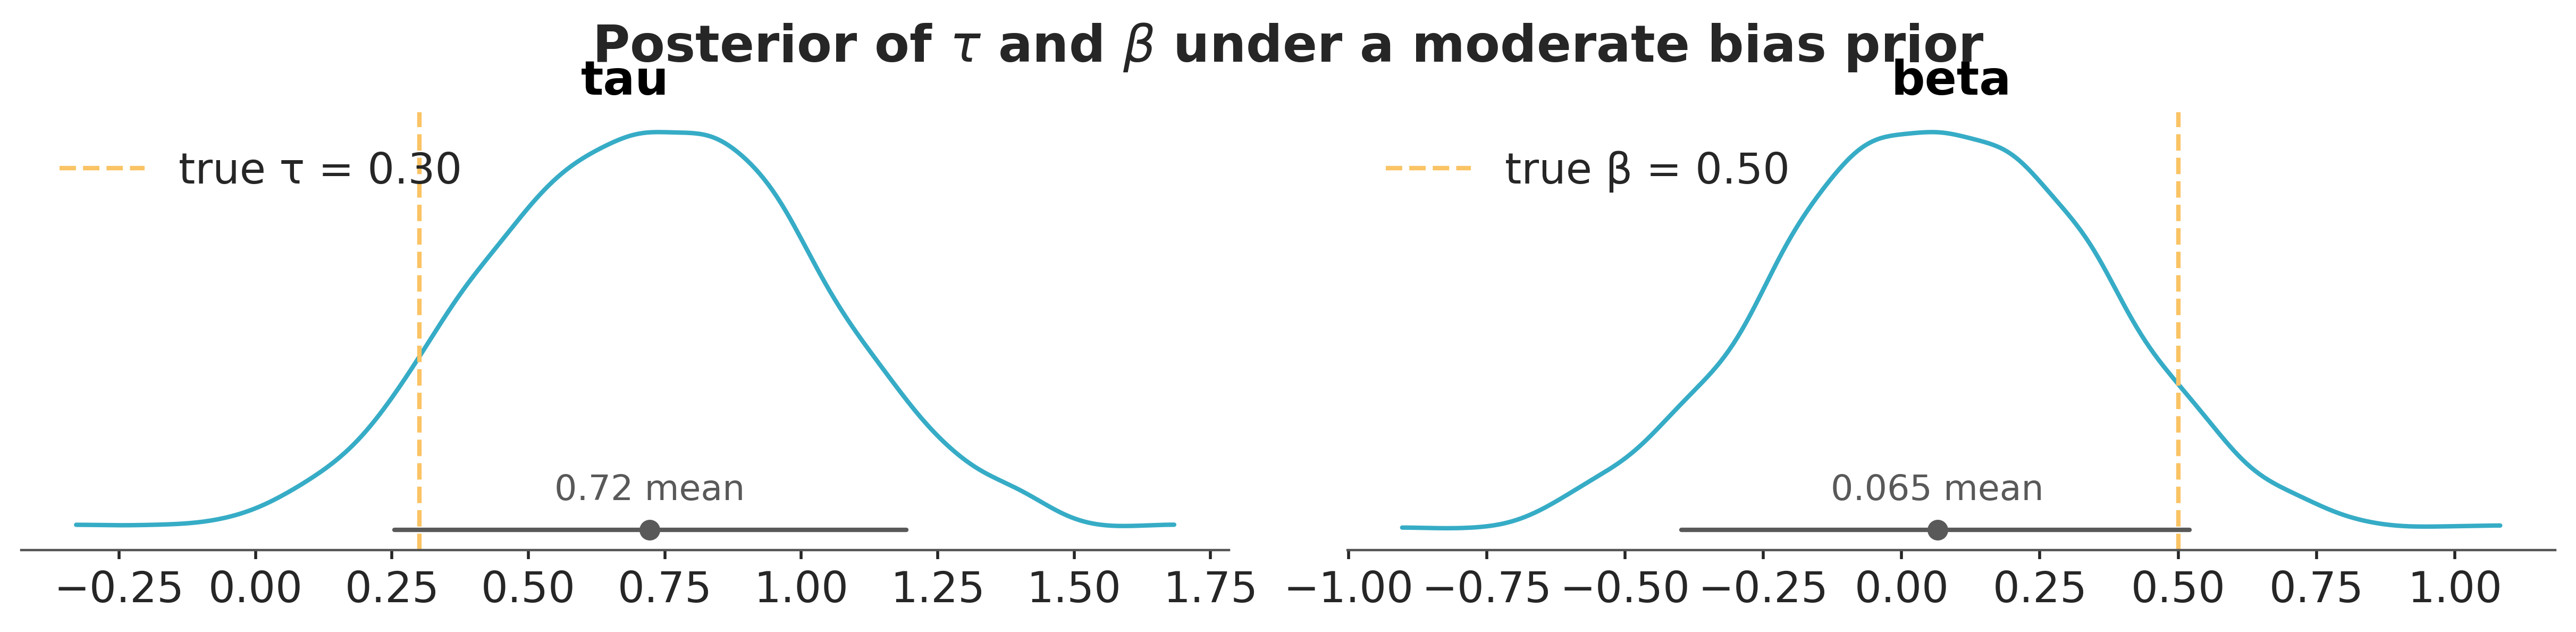

In [5]:
def gaussian_sensitivity_model(d_hat, sigma_d, tau_prior=(0.0, 1.0), bias_prior=(0.0, 0.3)):
    with pm.Model() as model:
        tau = pm.Normal("tau", mu=tau_prior[0], sigma=tau_prior[1])
        beta = pm.Normal("beta", mu=bias_prior[0], sigma=bias_prior[1])
        observed_effect = pm.Deterministic("observed_effect", tau + beta)
        pm.Normal("d_hat", mu=observed_effect, sigma=sigma_d, observed=d_hat)
    return model


with gaussian_sensitivity_model(d_hat, sigma_d, bias_prior=(0.0, 0.3)):
    idata_moderate = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

az.plot_dist(idata_moderate, var_names=["tau", "beta"])
axes = plt.gcf().axes
axes[0].axvline(TRUE_TAU, color="C2", linestyle="--", label=f"true τ = {TRUE_TAU:.2f}")
axes[0].legend()
axes[1].axvline(TRUE_BIAS, color="C2", linestyle="--", label=f"true β = {TRUE_BIAS:.2f}")
axes[1].legend()
plt.suptitle(r"Posterior of $\tau$ and $\beta$ under a moderate bias prior", y=1.05)

The posterior of $\tau$ is centred above zero; the posterior of $\beta$ is non-zero, pulled by the prior. The data informed the sum; the prior shapes the decomposition.

### Tipping-point analysis under a Gaussian outcome

The model with a flat prior on $\tau$ and a Gaussian prior on $\beta$ is fully conjugate; the posterior is a closed-form bivariate Normal that we can compute analytically. This lets us trace the tipping point — the bias prior strength at which the posterior probability of a positive treatment effect drops below the team's decision threshold.

In [6]:
def gaussian_sensitivity_posterior(
    d_hat, sigma_d, tau_prior_sd, bias_prior_sd, tau_prior_mean=0.0, bias_prior_mean=0.0
):
    """Closed-form posterior over (tau, beta) given the observed effect."""
    prior_precision = np.diag([1.0 / tau_prior_sd**2, 1.0 / bias_prior_sd**2])
    F = np.array([[1.0, 1.0]])
    data_precision = F.T @ F / sigma_d**2
    post_precision = prior_precision + data_precision
    post_cov = np.linalg.inv(post_precision)
    prior_mean = np.array([tau_prior_mean, bias_prior_mean])
    rhs = prior_precision @ prior_mean + F.flatten() * d_hat / sigma_d**2
    post_mean = post_cov @ rhs
    return post_mean, post_cov


# Verify analytical agrees with MCMC under the moderate prior
post_mean_anly, post_cov_anly = gaussian_sensitivity_posterior(
    d_hat, sigma_d, tau_prior_sd=1.0, bias_prior_sd=0.3
)
mcmc_summary = az.summary(idata_moderate, var_names=["tau", "beta"], kind="stats")[["mean", "sd"]]
analytical_summary = pd.DataFrame(
    {"mean": post_mean_anly, "sd": np.sqrt(np.diag(post_cov_anly))},
    index=["tau", "beta"],
)
pd.concat({"MCMC": mcmc_summary, "Analytical": analytical_summary}, axis=1).round(3)

MCMC       Analytical       
       mean    sd       mean     sd
tau    0.72   0.3      0.722  0.299
beta  0.065  0.29      0.065  0.287

The two posteriors agree. The analytical form carries the sweep.

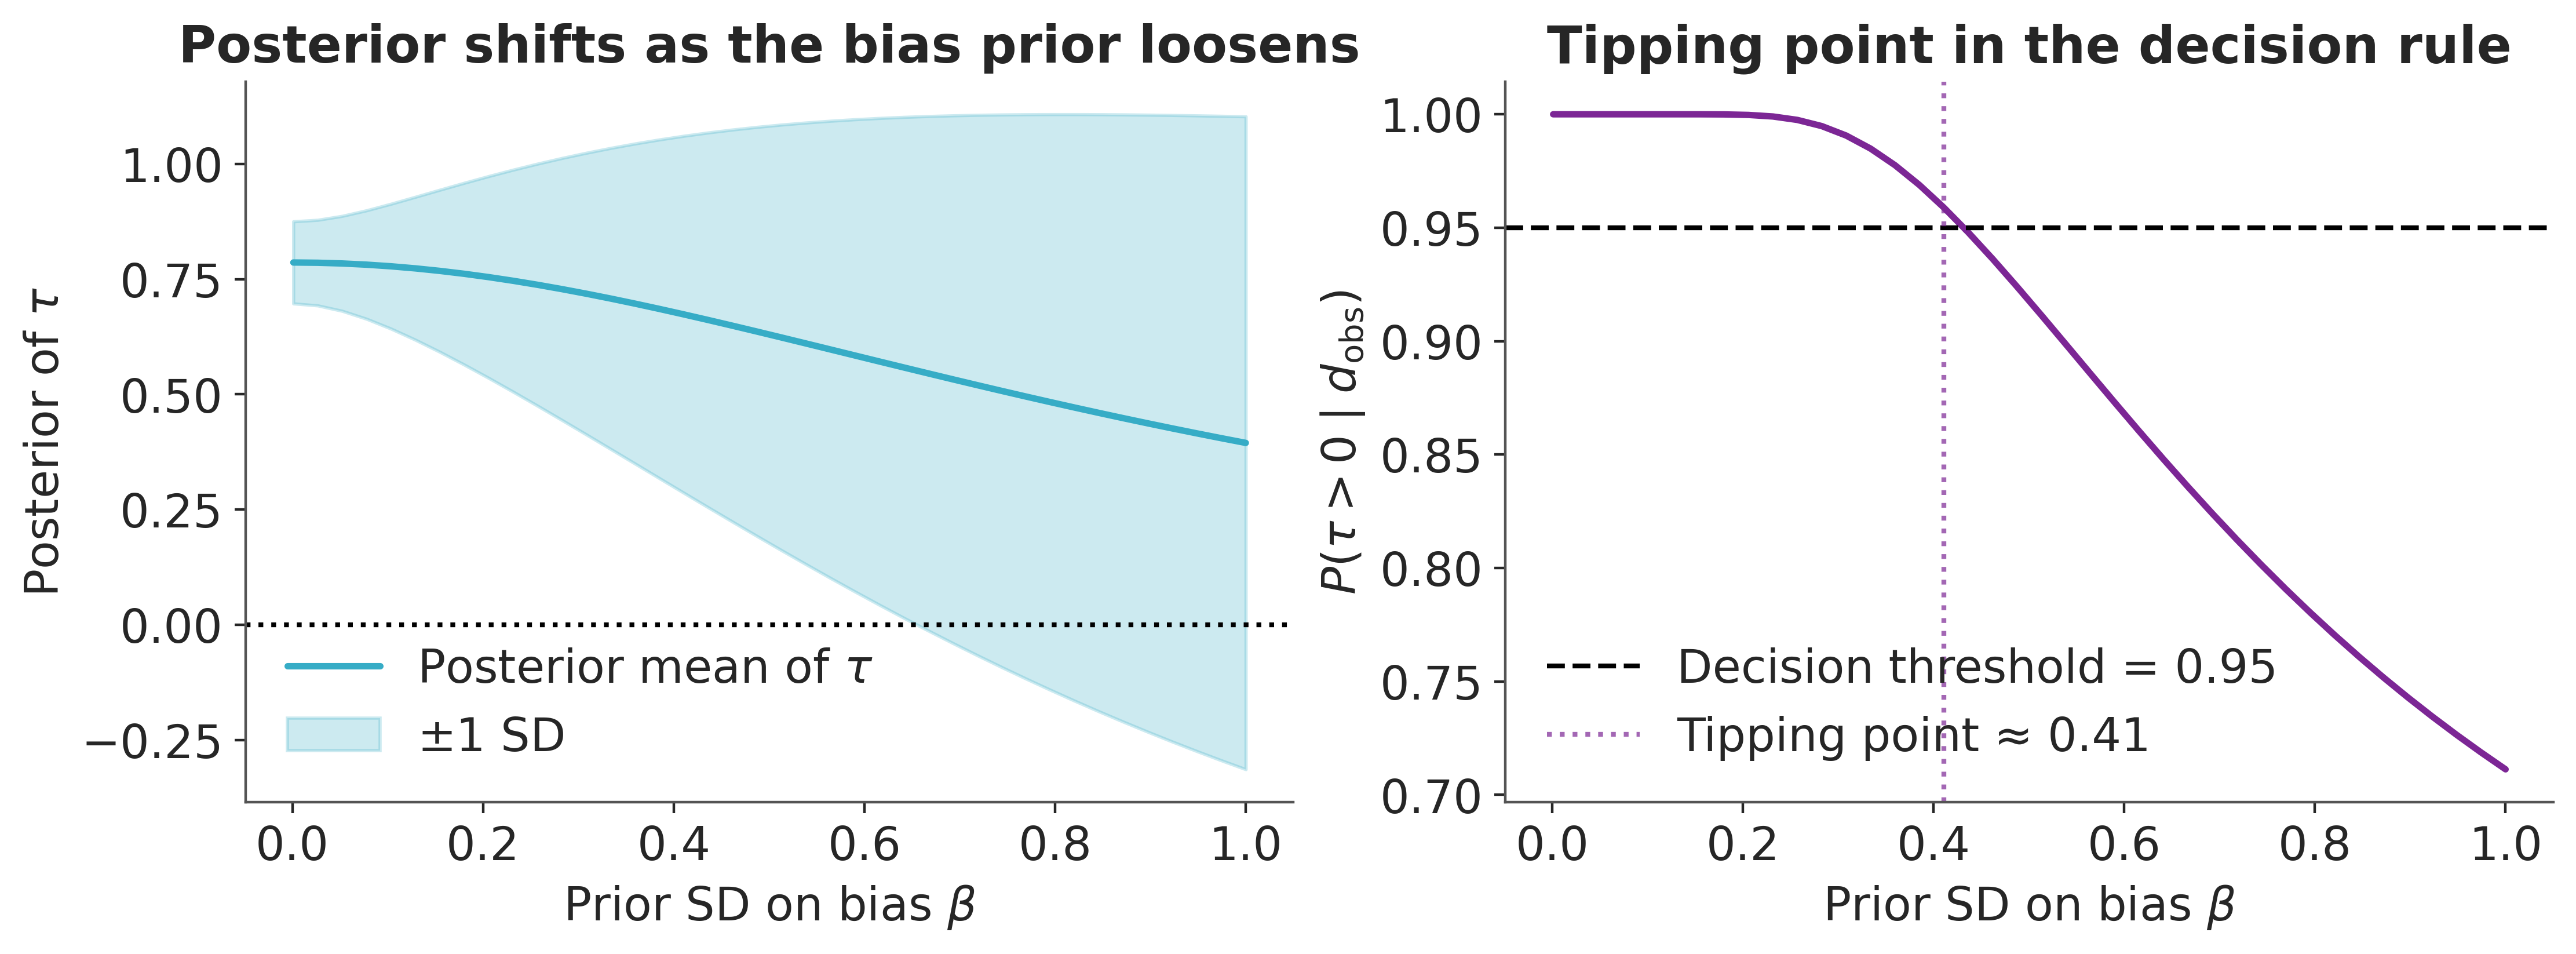

In [7]:
from scipy import stats

bias_sd_grid = np.linspace(0.001, 1.0, 40)
sweep_records = []
for bias_sd in bias_sd_grid:
    pm_a, pc_a = gaussian_sensitivity_posterior(
        d_hat, sigma_d, tau_prior_sd=1.0, bias_prior_sd=bias_sd
    )
    tau_mean, tau_sd = pm_a[0], np.sqrt(pc_a[0, 0])
    prob_positive = 1.0 - stats.norm.cdf(0.0, loc=tau_mean, scale=tau_sd)
    sweep_records.append(
        {"bias_sd": bias_sd, "tau_mean": tau_mean, "tau_sd": tau_sd, "prob_positive": prob_positive}
    )
sweep_df = pd.DataFrame(sweep_records)

decision_threshold = 0.95
above_threshold = sweep_df[sweep_df["prob_positive"] >= decision_threshold]
tipping_point = above_threshold["bias_sd"].max() if len(above_threshold) else np.nan

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    sweep_df["bias_sd"],
    sweep_df["tau_mean"],
    linewidth=2,
    color="C0",
    label=r"Posterior mean of $\tau$",
)
axes[0].fill_between(
    sweep_df["bias_sd"],
    sweep_df["tau_mean"] - sweep_df["tau_sd"],
    sweep_df["tau_mean"] + sweep_df["tau_sd"],
    alpha=0.25,
    color="C0",
    label=r"$\pm 1$ SD",
)
axes[0].axhline(0.0, color="black", linestyle=":")
axes[0].set_xlabel(r"Prior SD on bias $\beta$")
axes[0].set_ylabel(r"Posterior of $\tau$")
axes[0].set_title("Posterior shifts as the bias prior loosens")
axes[0].legend()

axes[1].plot(sweep_df["bias_sd"], sweep_df["prob_positive"], linewidth=2, color="C3")
axes[1].axhline(
    decision_threshold,
    color="black",
    linestyle="--",
    label=f"Decision threshold = {decision_threshold}",
)
if not np.isnan(tipping_point):
    axes[1].axvline(
        tipping_point,
        color="C3",
        linestyle=":",
        alpha=0.7,
        label=f"Tipping point ≈ {tipping_point:.2f}",
    )
axes[1].set_xlabel(r"Prior SD on bias $\beta$")
axes[1].set_ylabel(r"$P(\tau > 0 \mid d_{\text{obs}})$")
axes[1].set_title("Tipping point in the decision rule")
axes[1].legend();

Read the left panel from left to right: as the analyst loosens their prior on the bias, the posterior mean of $\tau$ drifts downward and the posterior interval widens. Read the right panel: there is a bias prior strength at which the posterior probability of a positive effect falls below the conventional decision threshold. The tipping point is not a refutation of the experiment — it is a price tag. To assert a positive effect requires a stated belief that the bias prior is *tighter* than the tipping point. The honest version of the conversation with stakeholders runs through this number. The posterior is what makes that conversation possible: the same inference machinery that reads the experiment's results in a clean world is what traces the contour of its fragility here. The question has changed from what the treatment did to which prior commitments on the unmeasured bias are required to believe that it did anything; the machinery has not.

The same machinery runs on the log-odds scale. Before mapping the full topology of the bias-prior space, we confirm that the one-dimensional fragility picture is not an artefact of the Gaussian likelihood.

## The same machinery on a binary outcome

The conversion-rate version of the experiment uses the same structural model on the log-odds scale. The bias parameter now lives on the logit, but the framing is identical: the observed log-odds difference is the sum of a treatment effect and an unmeasured-confounder contribution, and a prior over the latter is the only thing that separates them.

In [8]:
def simulate_quasi_experimental_bernoulli(N, baseline_rate, true_tau_logit, true_bias_logit, rng):
    from scipy.special import expit

    p_A = expit(np.log(baseline_rate / (1 - baseline_rate)))
    p_B = expit(np.log(baseline_rate / (1 - baseline_rate)) + true_tau_logit + true_bias_logit)
    n_A = rng.binomial(N, p_A)
    n_B = rng.binomial(N, p_B)
    return n_A, n_B, p_A, p_B


BASELINE_RATE_B = 0.10
TRUE_TAU_LOGIT = 0.15
TRUE_BIAS_LOGIT = 0.30

n_A_obs, n_B_obs, p_A_true, p_B_true = simulate_quasi_experimental_bernoulli(
    N=8000,
    baseline_rate=BASELINE_RATE_B,
    true_tau_logit=TRUE_TAU_LOGIT,
    true_bias_logit=TRUE_BIAS_LOGIT,
    rng=rng,
)
print(f"Observed conversions: A = {n_A_obs}/8000, B = {n_B_obs}/8000")
print(f"True p_A = {p_A_true:.4f}, p_B (with bias) = {p_B_true:.4f}")

Observed conversions: A = 834/8000, B = 1165/8000
True p_A = 0.1000, p_B (with bias) = 0.1484


In [9]:
def bernoulli_sensitivity_model(
    n_A, n_B, N, baseline_logit_prior=(-2.0, 0.5), tau_prior=(0.0, 0.5), bias_prior=(0.0, 0.3)
):
    with pm.Model() as model:
        logit_p_A = pm.Normal(
            "logit_p_A", mu=baseline_logit_prior[0], sigma=baseline_logit_prior[1]
        )
        tau = pm.Normal("tau", mu=tau_prior[0], sigma=tau_prior[1])
        beta = pm.Normal("beta", mu=bias_prior[0], sigma=bias_prior[1])
        logit_p_B = pm.Deterministic("logit_p_B", logit_p_A + tau + beta)
        p_A = pm.Deterministic("p_A", pm.math.invlogit(logit_p_A))
        p_B = pm.Deterministic("p_B", pm.math.invlogit(logit_p_B))
        pm.Binomial("obs_A", n=N, p=p_A, observed=n_A)
        pm.Binomial("obs_B", n=N, p=p_B, observed=n_B)
    return model


tipping_records_bern = []
for bias_sd in [0.05, 0.15, 0.30, 0.50, 0.80]:
    with bernoulli_sensitivity_model(n_A_obs, n_B_obs, N=8000, bias_prior=(0.0, bias_sd)):
        idata = pm.sample(
            draws=1000,
            tune=1000,
            chains=2,
            target_accept=0.95,
            random_seed=RANDOM_SEED,
            progressbar=False,
        )
    tau_samples = idata.posterior["tau"].values.flatten()
    tipping_records_bern.append(
        {
            "bias_sd": bias_sd,
            "tau_mean": tau_samples.mean(),
            "tau_sd": tau_samples.std(),
            "prob_positive": float((tau_samples > 0).mean()),
        }
    )
tipping_bern_df = pd.DataFrame(tipping_records_bern)
tipping_bern_df.round(3)

NUTS[nutpie]: [logit_p_A, tau, beta]
NUTS[nutpie]: [logit_p_A, tau, beta]
NUTS[nutpie]: [logit_p_A, tau, beta]
NUTS[nutpie]: [logit_p_A, tau, beta]
NUTS[nutpie]: [logit_p_A, tau, beta]


,bias_sd,tau_mean,tau_sd,prob_positive
0,0.05,0.369,0.070,1.000
1,0.15,0.358,0.146,0.998
2,0.30,0.273,0.267,0.835
3,0.50,0.191,0.342,0.716
4,0.80,0.110,0.401,0.600


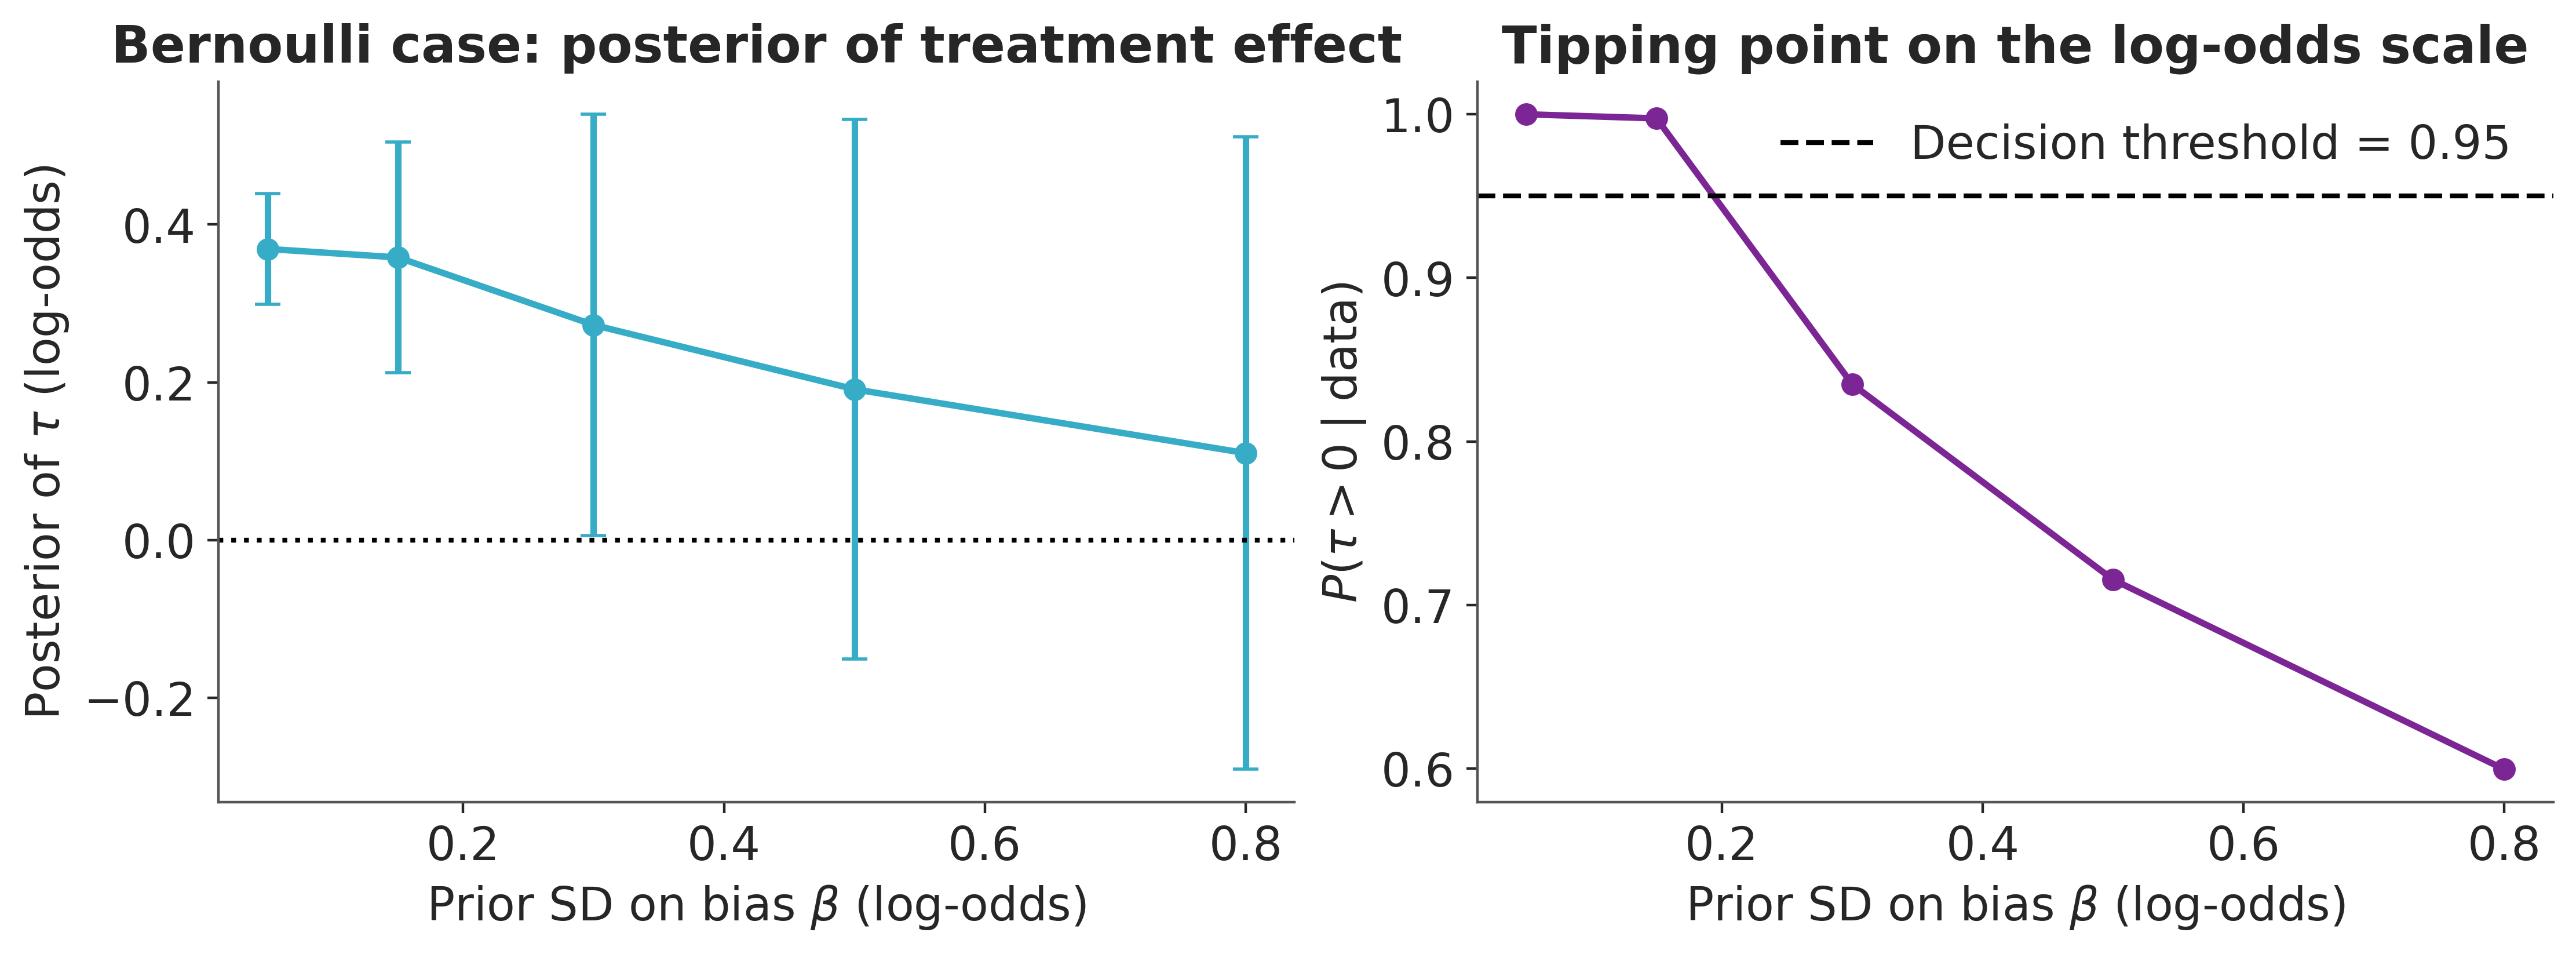

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(
    tipping_bern_df["bias_sd"],
    tipping_bern_df["tau_mean"],
    yerr=tipping_bern_df["tau_sd"],
    marker="o",
    linewidth=2,
    capsize=4,
)
axes[0].axhline(0.0, color="black", linestyle=":")
axes[0].set_xlabel(r"Prior SD on bias $\beta$ (log-odds)")
axes[0].set_ylabel(r"Posterior of $\tau$ (log-odds)")
axes[0].set_title("Bernoulli case: posterior of treatment effect")

axes[1].plot(
    tipping_bern_df["bias_sd"],
    tipping_bern_df["prob_positive"],
    marker="o",
    linewidth=2,
    color="C3",
)
axes[1].axhline(
    decision_threshold,
    color="black",
    linestyle="--",
    label=f"Decision threshold = {decision_threshold}",
)
axes[1].set_xlabel(r"Prior SD on bias $\beta$ (log-odds)")
axes[1].set_ylabel(r"$P(\tau > 0 \mid \text{data})$")
axes[1].set_title("Tipping point on the log-odds scale")
axes[1].legend();

The shape of the curve confirms what the Gaussian case showed: the decision rule loses confidence as the prior on bias widens, and the tipping point is identifiable on the log-odds scale just as it was on the revenue scale. The E-value of {cite:p}`vanderweele2017sensitivity` corresponds, roughly, to the bias magnitude at which a frequentist decision would tip; the Bayesian curve is the full posterior over that commitment. One dimension, two likelihoods, the same fragility picture. The complete audit — both dimensions of the bias prior, the full region of commitments the conclusion can survive — is the surface below.

### The sensitivity surface

Both the Gaussian and the binary sweep moved one dimension of the bias prior. The complete audit requires the other: a map of the full region of $(\mu_\beta, \sigma_\beta)$ commitments the experiment can survive. The sweep below opens the line into a surface.

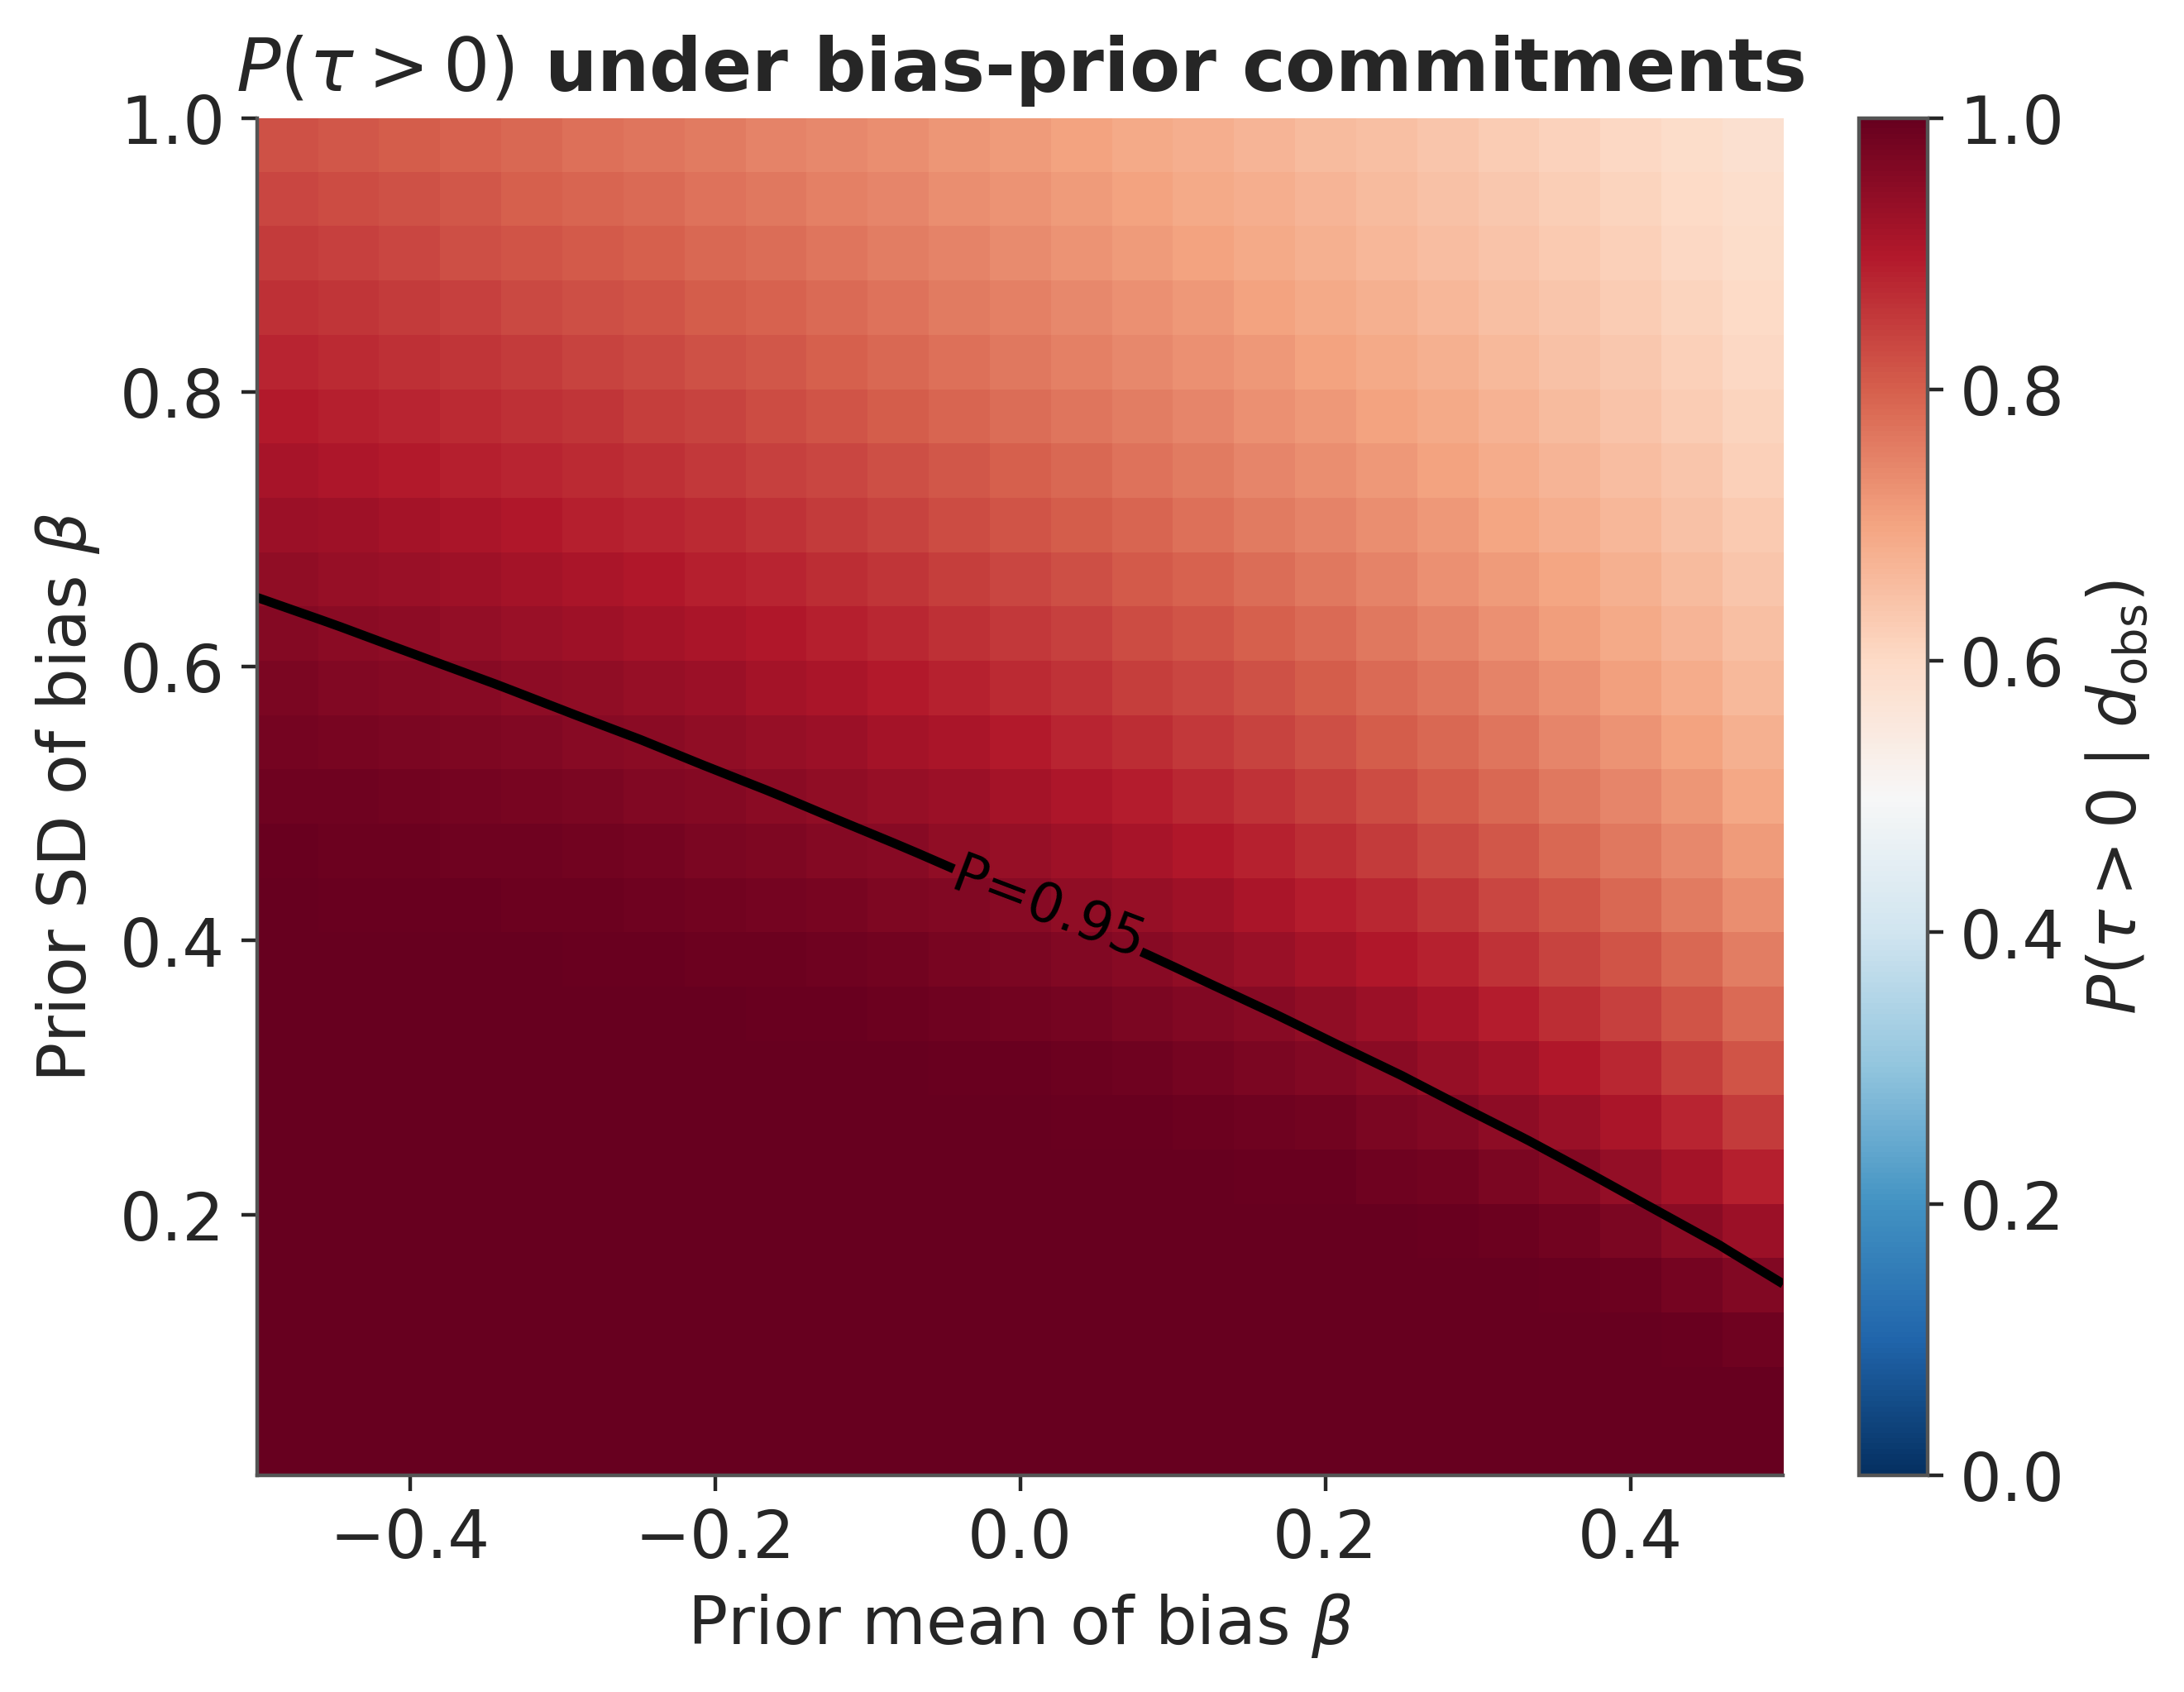

In [11]:
bias_mu_grid = np.linspace(-0.5, 0.5, 25)
bias_sd_grid_2d = np.linspace(0.01, 1.0, 25)
prob_grid = np.zeros((len(bias_sd_grid_2d), len(bias_mu_grid)))

for i, b_sd in enumerate(bias_sd_grid_2d):
    for j, b_mu in enumerate(bias_mu_grid):
        pm_a, pc_a = gaussian_sensitivity_posterior(
            d_hat, sigma_d, tau_prior_sd=1.0, bias_prior_sd=b_sd, bias_prior_mean=b_mu
        )
        tau_mean, tau_sd = pm_a[0], np.sqrt(pc_a[0, 0])
        prob_grid[i, j] = 1.0 - stats.norm.cdf(0.0, loc=tau_mean, scale=tau_sd)

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(
    prob_grid,
    origin="lower",
    aspect="auto",
    extent=[bias_mu_grid.min(), bias_mu_grid.max(), bias_sd_grid_2d.min(), bias_sd_grid_2d.max()],
    cmap="RdBu_r",
    vmin=0.0,
    vmax=1.0,
)
contour = ax.contour(
    bias_mu_grid,
    bias_sd_grid_2d,
    prob_grid,
    levels=[0.5, decision_threshold],
    colors=["white", "black"],
    linewidths=[1.2, 2.0],
)
ax.clabel(contour, fmt={0.5: "P=0.5", decision_threshold: f"P={decision_threshold}"})
ax.set_xlabel(r"Prior mean of bias $\beta$")
ax.set_ylabel(r"Prior SD of bias $\beta$")
ax.set_title(r"$P(\tau > 0)$ under bias-prior commitments")
plt.colorbar(im, ax=ax, label=r"$P(\tau > 0 \mid d_{\text{obs}})$");

The decision threshold contour partitions the bias-prior plane into a region where the experiment is defensible and a region where it is not. The analyst who wants to claim a positive effect commits to a point inside the inner contour. The dissenter who wants to claim the effect is artefactual commits to a point outside it. The graph does not tell anyone who is right. It tells both parties exactly what they are disagreeing about: which region of the bias-prior plane their prior commitments occupy, and whether that region sits inside or outside the contour of defensibility. The audit has a legible geometry.

## Robustness as a posterior question

The randomisation gap is not closed by a sensitivity analysis. It is mapped. The analyst who runs the sweep above has not proved the experiment robust; they have produced an audit-able exhibit of which bias commitments the experiment can survive, and which it cannot. The audit is the deliverable.

This shifts what counts as honest reporting. The headline number from a quasi-experiment is no longer the point estimate of the treatment effect; it is the *tipping point* — the prior on the bias at which the conclusion turns. The sensitivity surface extends this from a point to a topology: the full region of bias-prior commitments the experiment can survive, with its boundary drawn as a contour. Two analysts holding the same data and disagreeing about a conclusion are not disagreeing about the data. They occupy different coordinates in the bias-prior plane, and the surface tells them precisely which commitment separates them.

The first notebook used the posterior to ask what an experiment will probably say. This one uses the posterior to ask what the experiment did say, once the assumption of clean identification is itself a parameter. The next will use the posterior to ask what a whole series of experiments jointly implies. In each: an assumption a conventional analysis leaves implicit becomes a parameter with a posterior — something to argue about rather than assume. The posterior is the constant; the question changes. We have just seen the second.

## Authors

- Authored by [Nathaniel Forde](https://nathanielf.github.io/) in May 2026.

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [12]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Mon, 01 Jun 2026

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.14.0

pytensor: 3.0.3
xarray  : 2026.4.0

arviz     : 1.1.0
matplotlib: 3.10.9
numpy     : 2.3.5
pandas    : 2.3.3
pymc      : 6.0.1
pytensor  : 3.0.3
scipy     : 1.17.1
seaborn   : 0.13.2

Watermark: 2.6.0



:::{include} ../page_footer.md
:::